Overall dropout rate: 31.2%

B1: Dropout rate by gender


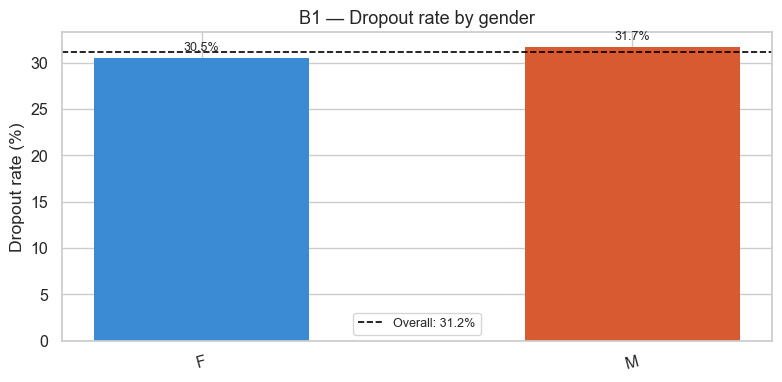


  gender dropout rates:
    F                                   30.5% ▼ below avg
    M                                   31.7% ▲ above avg
  Saved → ./outputs/block_b/B1_dropout_gender.png

B2: Dropout rate by age band


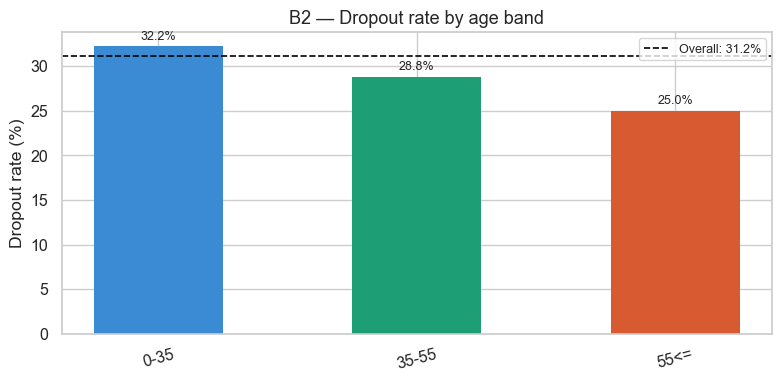


  age_band dropout rates:
    0-35                                32.2% ▲ above avg
    35-55                               28.8% ▼ below avg
    55<=                                25.0% ▼ below avg
  Saved → ./outputs/block_b/B2_dropout_age.png

B3: Dropout rate by prior education level


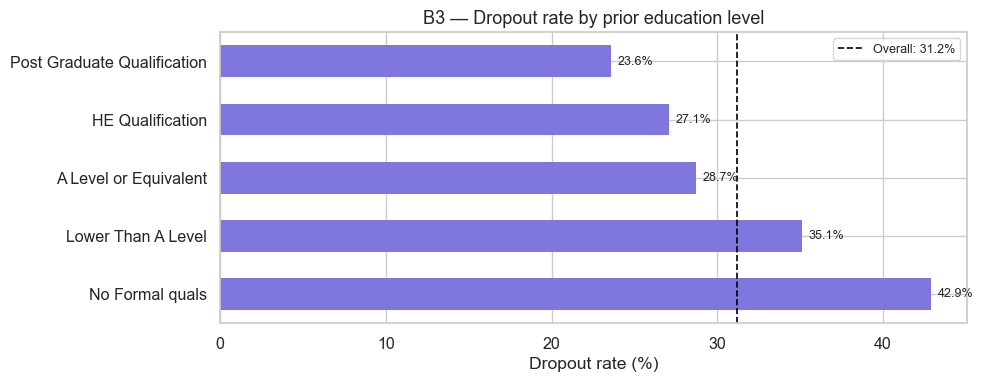


  highest_education dropout rates:
    No Formal quals                     42.9% ▲ above avg
    Lower Than A Level                  35.1% ▲ above avg
    A Level or Equivalent               28.7% ▼ below avg
    HE Qualification                    27.1% ▼ below avg
    Post Graduate Qualification         23.6% ▼ below avg
  Saved → ./outputs/block_b/B3_dropout_education.png

B4: Dropout rate by IMD band


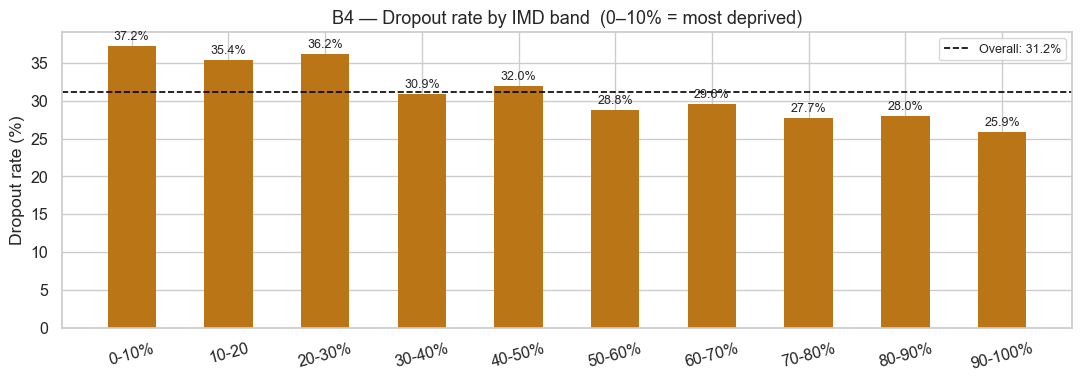


  imd_band dropout rates:
    0-10%                               37.2% ▲ above avg
    10-20                               35.4% ▲ above avg
    20-30%                              36.2% ▲ above avg
    30-40%                              30.9% ▼ below avg
    40-50%                              32.0% ▲ above avg
    50-60%                              28.8% ▼ below avg
    60-70%                              29.6% ▼ below avg
    70-80%                              27.7% ▼ below avg
    80-90%                              28.0% ▼ below avg
    90-100%                             25.9% ▼ below avg
  Saved → ./outputs/block_b/B4_dropout_imd.png

B5: Dropout rate by disability status


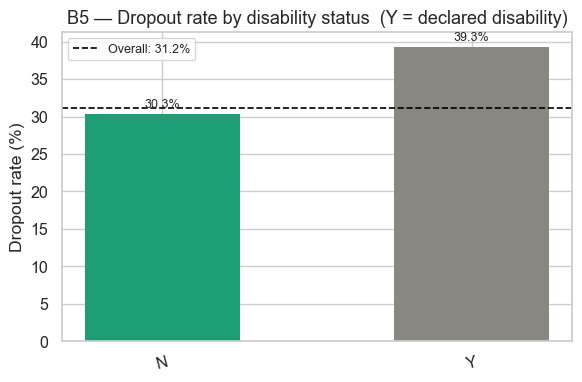


  disability dropout rates:
    N                                   30.3% ▼ below avg
    Y                                   39.3% ▲ above avg
  Saved → ./outputs/block_b/B5_dropout_disability.png

B6: Dropout rate by previous attempts


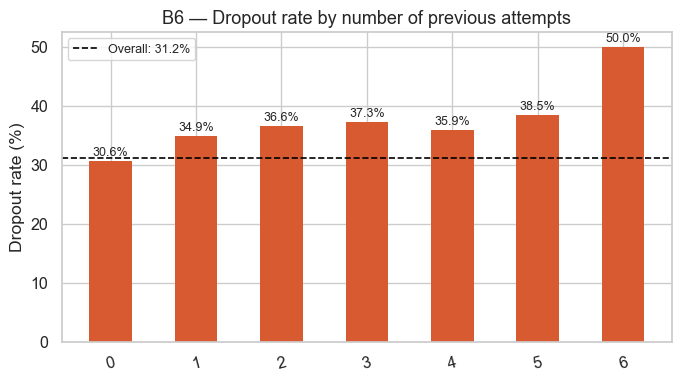


  num_of_prev_attempts dropout rates:
    0                                   30.6% ▼ below avg
    1                                   34.9% ▲ above avg
    2                                   36.6% ▲ above avg
    3                                   37.3% ▲ above avg
    4                                   35.9% ▲ above avg
    5                                   38.5% ▲ above avg
    6                                   50.0% ▲ above avg
  Saved → ./outputs/block_b/B6_dropout_attempts.png

B7: Dropout rate by course module


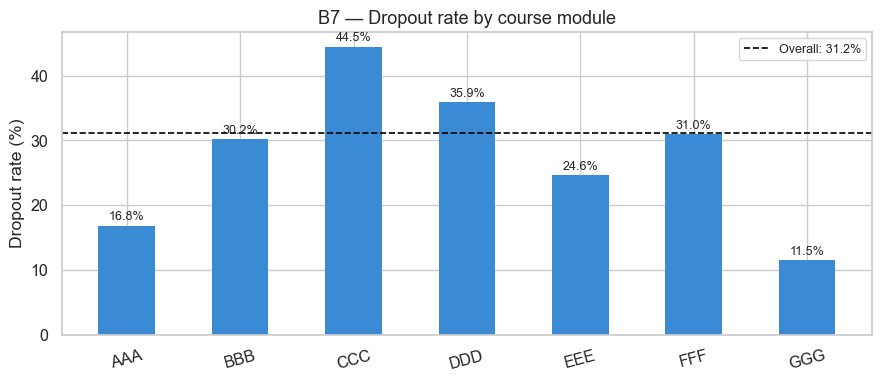


  code_module dropout rates:
    AAA                                 16.8% ▼ below avg
    BBB                                 30.2% ▼ below avg
    CCC                                 44.5% ▲ above avg
    DDD                                 35.9% ▲ above avg
    EEE                                 24.6% ▼ below avg
    FFF                                 31.0% ▼ below avg
    GGG                                 11.5% ▼ below avg
  Saved → ./outputs/block_b/B7_dropout_module.png

B8: BONUS — Dropout rate by gender × education level


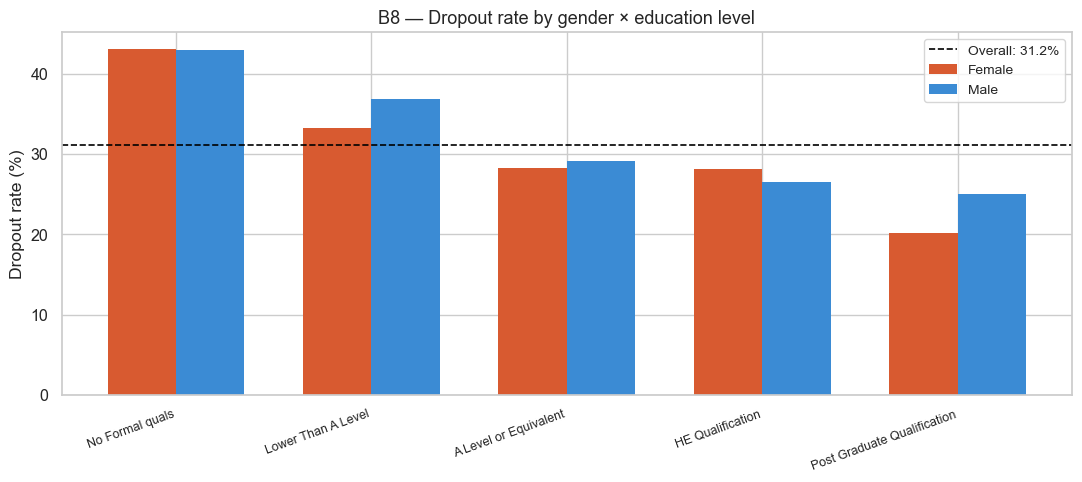

  Saved → ./outputs/block_b/B8_dropout_gender_x_education.png

gender                          F     M
highest_education                      
No Formal quals              43.0  42.9
Lower Than A Level           33.2  36.8
A Level or Equivalent        28.2  29.1
HE Qualification             28.1  26.5
Post Graduate Qualification  20.2  25.0

BLOCK B COMPLETE — Key Risk Factors

  Highest-risk group per feature:
  gender                         ▲ M → 31.7%
  age_band                       ▲ 0-35 → 32.2%
  highest_education              ▲ No Formal quals → 42.9%
  disability                     ▲ Y → 39.3%
  num_of_prev_attempts           ▲ 6 → 50.0%
  code_module                    ▲ CCC → 44.5%

  Overall dropout rate: 31.2%
  Charts saved to: ./outputs/block_b/

─────────────────────────────────────────────────
Next → Run block_c_correlation.py
─────────────────────────────────────────────────



In [1]:
"""
=============================================================
Phase 2 — Block B: Dropout Rates by Feature
=============================================================
Goal: For each key feature, calculate the dropout rate per group
      and visualise it. This answers: WHO is most at risk?

The dashed line on every chart = overall dropout rate (baseline).
Any bar above that line = above-average risk group.
Any bar below = below-average risk group.
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Config ────────────────────────────────────────────────────
DATA_PATH   = './data/'
OUTPUT_PATH = './outputs/block_b/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}
COLOR_LIST = list(COLORS.values())

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# ── Load data ─────────────────────────────────────────────────
si = pd.read_csv(DATA_PATH + 'studentInfo.csv')
si['dropout'] = (si['final_result'] == 'Withdrawn').astype(int)

# Overall dropout rate — used as a reference line on every chart
OVERALL_RATE = si['dropout'].mean() * 100
print(f"Overall dropout rate: {OVERALL_RATE:.1f}%\n")


# =============================================================
# HELPER: plot_dropout_rate
# =============================================================
# Rather than rewriting the same chart code 7 times, we define
# one function that handles both vertical and horizontal bar charts.
#
# Parameters:
#   df         : DataFrame (studentInfo, possibly filtered)
#   col        : column to group by (e.g. 'gender')
#   title      : chart title string
#   color      : single colour string OR list of colours per bar
#   filename   : output filename (saved inside OUTPUT_PATH)
#   order      : optional list to control bar ordering
#   horizontal : if True, draw horizontal bars (better for long labels)
#   figsize    : (width, height) tuple

def plot_dropout_rate(df, col, title, color, filename,
                      order=None, horizontal=False, figsize=(8, 4)):

    # ── Step 1: calculate dropout rate per group ──────────────
    # groupby(col)['dropout'].mean() gives the proportion of students
    # in each group who withdrew. Multiply by 100 for a percentage.
    rate = (
        df.groupby(col)['dropout']
          .mean()
          .mul(100)
          .round(1)
    )

    # Reorder bars if a custom order is provided
    if order:
        # Filter order to only include values that exist in the data
        rate = rate.reindex([o for o in order if o in rate.index])

    # ── Step 2: draw the chart ────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    if horizontal:
        # Horizontal bar chart (good for long category labels)
        bars = ax.barh(rate.index, rate.values, color=color, edgecolor='none', height=0.55)

        # Dashed vertical reference line at the overall dropout rate
        ax.axvline(OVERALL_RATE, color='black', linestyle='--',
                   linewidth=1.2, label=f'Overall: {OVERALL_RATE:.1f}%')

        # Label each bar with its exact dropout %
        for bar, val in zip(bars, rate.values):
            ax.text(val + 0.4,
                    bar.get_y() + bar.get_height() / 2,
                    f"{val}%", va='center', fontsize=9)

        ax.set_xlabel('Dropout rate (%)')

    else:
        # Vertical bar chart (good for short category labels)
        bars = ax.bar(rate.index, rate.values, color=color, edgecolor='none', width=0.5)

        # Dashed horizontal reference line at the overall dropout rate
        ax.axhline(OVERALL_RATE, color='black', linestyle='--',
                   linewidth=1.2, label=f'Overall: {OVERALL_RATE:.1f}%')

        # Label each bar with its exact dropout %
        for bar, val in zip(bars, rate.values):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    val + 0.4, f"{val}%",
                    ha='center', va='bottom', fontsize=9)

        ax.set_ylabel('Dropout rate (%)')
        ax.tick_params(axis='x', rotation=15)

    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)
    plt.tight_layout()

    path = os.path.join(OUTPUT_PATH, filename)
    plt.savefig(path, dpi=150)
    plt.show()

    # Print the raw numbers below the chart for reference
    print(f"\n  {col} dropout rates:")
    for group, val in rate.items():
        marker = " ▲ above avg" if val > OVERALL_RATE else " ▼ below avg"
        print(f"    {str(group):<35} {val:.1f}%{marker}")
    print(f"  Saved → {path}\n")


# =============================================================
# B1: Dropout rate by gender
# =============================================================
# Question: Do male or female students drop out at higher rates?
# Even a small gap is worth noting for equity recommendations.

print("B1: Dropout rate by gender")
plot_dropout_rate(
    df=si,
    col='gender',
    title="B1 — Dropout rate by gender",
    color=[COLORS['blue'], COLORS['coral']],
    filename="B1_dropout_gender.png"
)


# =============================================================
# B2: Dropout rate by age band
# =============================================================
# Question: Are older students at higher risk?
# Older students may juggle work and family alongside study.

print("B2: Dropout rate by age band")
plot_dropout_rate(
    df=si,
    col='age_band',
    order=['0-35', '35-55', '55<='],
    title="B2 — Dropout rate by age band",
    color=COLOR_LIST[:3],
    filename="B2_dropout_age.png"
)


# =============================================================
# B3: Dropout rate by prior education level
# =============================================================
# Question: Does having more prior qualifications protect against dropout?
# We'd expect a downward trend (more education → lower dropout risk).

print("B3: Dropout rate by prior education level")
edu_order = [
    'No Formal quals',
    'Lower Than A Level',
    'A Level or Equivalent',
    'HE Qualification',
    'Post Graduate Qualification'
]
plot_dropout_rate(
    df=si,
    col='highest_education',
    order=edu_order,
    title="B3 — Dropout rate by prior education level",
    color=COLORS['purple'],
    filename="B3_dropout_education.png",
    horizontal=True,
    figsize=(10, 4)
)


# =============================================================
# B4: Dropout rate by IMD band (socioeconomic deprivation)
# =============================================================
# Question: Do students from more deprived areas drop out more?
# We'd expect a downward trend as deprivation decreases.
# We drop rows with missing imd_band for this analysis.

print("B4: Dropout rate by IMD band")
imd_order = [
    '0-10%', '10-20', '20-30%', '30-40%', '40-50%',
    '50-60%', '60-70%', '70-80%', '80-90%', '90-100%'
]
plot_dropout_rate(
    df=si.dropna(subset=['imd_band']),    # exclude missing IMD rows
    col='imd_band',
    order=imd_order,
    title="B4 — Dropout rate by IMD band  (0–10% = most deprived)",
    color=COLORS['amber'],
    filename="B4_dropout_imd.png",
    figsize=(11, 4)
)


# =============================================================
# B5: Dropout rate by disability status
# =============================================================
# Question: Do students with a declared disability face higher dropout risk?
# This is important for equity and support service recommendations.

print("B5: Dropout rate by disability status")
plot_dropout_rate(
    df=si,
    col='disability',
    title="B5 — Dropout rate by disability status  (Y = declared disability)",
    color=[COLORS['teal'], COLORS['gray']],
    filename="B5_dropout_disability.png",
    figsize=(6, 4)
)


# =============================================================
# B6: Dropout rate by number of previous attempts
# =============================================================
# Question: Do students who've already retaken this module drop out more?
# More attempts = more difficulty with the material → higher risk?

print("B6: Dropout rate by previous attempts")
plot_dropout_rate(
    df=si,
    col='num_of_prev_attempts',
    title="B6 — Dropout rate by number of previous attempts",
    color=COLORS['coral'],
    filename="B6_dropout_attempts.png",
    figsize=(7, 4)
)


# =============================================================
# B7: Dropout rate by course module
# =============================================================
# Question: Are some courses much harder to complete than others?
# Big variation here suggests course design might drive dropout,
# not just student characteristics.

print("B7: Dropout rate by course module")
plot_dropout_rate(
    df=si,
    col='code_module',
    title="B7 — Dropout rate by course module",
    color=COLORS['blue'],
    filename="B7_dropout_module.png",
    figsize=(9, 4)
)


# =============================================================
# B8: BONUS — Side-by-side comparison: gender × education level
# =============================================================
# Sometimes two features interact. Here we compare dropout rates
# across gender AND education level simultaneously using a grouped bar chart.
# This reveals whether education level matters differently for men vs women.

print("B8: BONUS — Dropout rate by gender × education level")

edu_order = [
    'No Formal quals',
    'Lower Than A Level',
    'A Level or Equivalent',
    'HE Qualification',
    'Post Graduate Qualification'
]

# Pivot table: rows = education level, columns = gender, values = dropout rate
pivot = (
    si.groupby(['highest_education', 'gender'])['dropout']
      .mean()
      .mul(100)
      .round(1)
      .unstack('gender')           # gender becomes column headers (F, M)
      .reindex(edu_order)
)

fig, ax = plt.subplots(figsize=(11, 5))

x      = np.arange(len(pivot.index))   # x positions for each education level
width  = 0.35                          # width of each bar

# Plot Female bars (left of each group) and Male bars (right)
bars_f = ax.bar(x - width/2, pivot['F'], width,
                color=COLORS['coral'], label='Female', edgecolor='none')
bars_m = ax.bar(x + width/2, pivot['M'], width,
                color=COLORS['blue'],  label='Male',   edgecolor='none')

# Overall reference line
ax.axhline(OVERALL_RATE, color='black', linestyle='--',
           linewidth=1.2, label=f'Overall: {OVERALL_RATE:.1f}%')

# x-axis labels = education levels (rotated for readability)
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Dropout rate (%)')
ax.set_title("B8 — Dropout rate by gender × education level", fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "B8_dropout_gender_x_education.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"  Saved → {path}\n")
print(pivot.to_string())


# =============================================================
# BLOCK B SUMMARY
# =============================================================
print("\n" + "=" * 55)
print("BLOCK B COMPLETE — Key Risk Factors")
print("=" * 55)

# Automatically identify the highest-risk group for each feature
features = {
    'gender':              None,
    'age_band':            ['0-35', '35-55', '55<='],
    'highest_education':   edu_order,
    'disability':          None,
    'num_of_prev_attempts': None,
    'code_module':         None,
}

print("\n  Highest-risk group per feature:")
for col, order in features.items():
    rate = si.dropna(subset=[col]).groupby(col)['dropout'].mean().mul(100)
    top_group = rate.idxmax()
    top_rate  = rate.max()
    arrow     = "▲" if top_rate > OVERALL_RATE else "—"
    print(f"  {col:<30} {arrow} {top_group} → {top_rate:.1f}%")

print(f"""
  Overall dropout rate: {OVERALL_RATE:.1f}%
  Charts saved to: {OUTPUT_PATH}

─────────────────────────────────────────────────
Next → Run block_c_correlation.py
─────────────────────────────────────────────────
""")